### Importing Libraries

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# library that will help to import dataset
from datasets import load_dataset

/usr/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Loading the File

In [2]:
emotion_dataset = load_dataset('dair-ai/emotion')
train_text      = emotion_dataset['train']['text']
train_label     = emotion_dataset['train']['label']

test_text       = emotion_dataset['test']['text']
test_label      = emotion_dataset['test']['label']

In [3]:
emotion_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [4]:
# Extracting the label_names 
label_names = emotion_dataset['train'].features['label'].names

In [5]:
# What are the labels 
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [6]:
# Creating a dataframes 
df_train = pd.DataFrame(
    {
        'text'  : train_text,
        'label' : [label_names[i] for i in train_label]
    }
)

df_test = pd.DataFrame(
    {
        'text'  : test_text,
        'label' : [label_names[i] for i in test_label]
    }
)
     

In [7]:
# Checking for null and nan
df_train.isnull().sum()

text     0
label    0
dtype: int64

### Lets do Exploratory Data Analysis

In [8]:
# Lets check the distribution of the target variable
df_train['label'].value_counts()

label
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

In [9]:
df_train['label'].value_counts().index

Index(['joy', 'sadness', 'anger', 'fear', 'love', 'surprise'], dtype='object', name='label')

<Axes: xlabel='label', ylabel='count'>

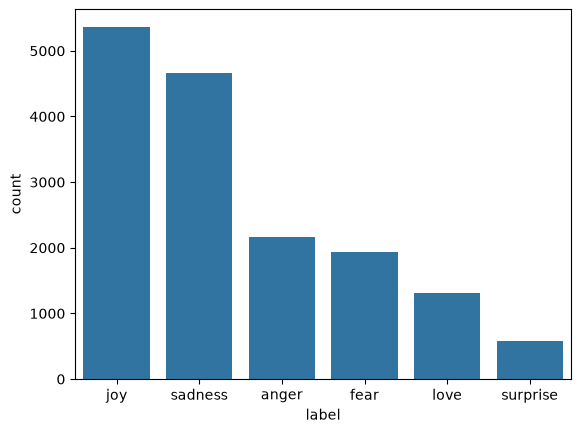

In [10]:
sns.countplot(x='label', data = df_train, order = df_train['label'].value_counts().index)

### Data Preprocessing for NLP
Tokenize the text, pad sequence to max length 50 and convert to numpy array 
Tokenization is the process of breaing the text into smaller units called token so model can process it as a number.

In [11]:
df_train

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


In [12]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 10000

tokenizer = Tokenizer(num_words=max_words, oov_token='')
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequenece = tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence = pad_sequences(train_sequence,maxlen=50,padding='post', truncating='post')
padded_test_sequence = pad_sequences(test_sequenece ,maxlen=50,padding='post', truncating='post')

train_labels = np.array(train_label)
test_labels  = np.array(test_label)

num_classes = len(np.unique(train_labels))
num_classes


print(f"Vocabulary Size: {len(tokenizer.word_index)}")
print(f"Max Sentence Length: {padded_train_sequence.shape[1]}")

I0000 00:00:1787660769.832574   21778 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Vocabulary Size: 15213
Max Sentence Length: 50


### Lets handle unequal class size i.e., imbalance classes
Calculate the class weight and use it in the model as the six classes have different distribution to correct for bias.

In [13]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(train_labels),
    y            = train_labels
)

class_weight_dict = dict(enumerate(class_weights))

In [14]:

from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

### Lets build some models

#### Simple RNN model

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU

rnn_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

rnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
     

/usr/lib/python3.14/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [16]:
rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequence, test_labels)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 43ms/step - accuracy: 0.1542 - loss: 1.9382 - val_accuracy: 0.0695 - val_loss: 1.8087
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.1516 - loss: 1.8053 - val_accuracy: 0.0885 - val_loss: 1.8027
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.1583 - loss: 1.7855 - val_accuracy: 0.1295 - val_loss: 1.7970
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.1663 - loss: 1.7745 - val_accuracy: 0.1290 - val_loss: 1.7894
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.1596 - loss: 1.7586 - val_accuracy: 0.1270 - val_loss: 1.8083
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.1789 - loss: 1.7394 - val_accuracy: 0.1555 - val_loss: 1.8111
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.1921 - loss: 1.7137 - val_accuracy: 0.1275 - val_loss: 1.8118
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1290 - loss: 1.7894
RNN Loss: 1.78942

#### LSTM Model 

In [17]:
lstm_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 53s 99ms/step - accuracy: 0.1534 - loss: 1.7946 - val_accuracy: 0.0335 - val_loss: 1.8043
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 50s 100ms/step - accuracy: 0.1416 - loss: 1.7935 - val_accuracy: 0.2845 - val_loss: 1.7847
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 79s 94ms/step - accuracy: 0.1636 - loss: 1.7902 - val_accuracy: 0.0845 - val_loss: 1.7985
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 48s 96ms/step - accuracy: 0.2255 - loss: 1.7150 - val_accuracy: 0.2650 - val_loss: 1.6889
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 57s 113ms/step - accuracy: 0.3687 - loss: 1.4457 - val_accuracy: 0.4100 - val_loss: 1.2224
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 91s 131ms/step - accuracy: 0.5246 - loss: 1.0283 - val_accuracy: 0.6120 - val_loss: 0.9020
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 59s 119ms/step - accuracy: 0.7216 - loss: 0.7242 - val_accuracy: 0.7475 - val_loss: 0.6612
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 89s 178ms/step - accuracy: 0.8153 - loss: 0.55

#### GRU Model

In [18]:
gru_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

gru_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")     

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 81s 148ms/step - accuracy: 0.1689 - loss: 1.7959 - val_accuracy: 0.0350 - val_loss: 1.7974
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 44s 87ms/step - accuracy: 0.1431 - loss: 1.7951 - val_accuracy: 0.3475 - val_loss: 1.7795
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 84ms/step - accuracy: 0.1693 - loss: 1.7944 - val_accuracy: 0.2890 - val_loss: 1.7831
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 82ms/step - accuracy: 0.1603 - loss: 1.7931 - val_accuracy: 0.1405 - val_loss: 1.8133
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 82ms/step - accuracy: 0.1816 - loss: 1.7905 - val_accuracy: 0.1275 - val_loss: 1.8110
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3475 - loss: 1.7795
GRU Loss: 1.7794972658157349
GRU Accuracy: 0.3474999964237213


#### Lets Rank and Select the Model

In [19]:
result_df = pd.DataFrame({
    'Model' : ['RNN', 'LSTM', 'GRU'],
    'Test Loss': [rnn_loss, lstm_loss, gru_loss],
    'Test Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]
    }).sort_values(by='Test Accuracy',ascending=False)
result_df

,Model,Test Loss,Test Accuracy
1,LSTM,0.393802,0.8930
2,GRU,1.779497,0.3475
0,RNN,1.789427,0.1290


#### Lets try Advance BIderectional GRU
Enhance GRU with Bidirectional layers, 300D embeddings, and 0.5 dropout regularization.

In [20]:

from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim = max_words, output_dim = 300 , input_length = 50),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') 
])

BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

BiGRU.summary()

/usr/lib/python3.14/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 112s 210ms/step - accuracy: 0.5510 - loss: 1.0833 - val_accuracy: 0.8840 - val_loss: 0.3800
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 98s 196ms/step - accuracy: 0.9155 - loss: 0.2474 - val_accuracy: 0.9265 - val_loss: 0.1717
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 142s 196ms/step - accuracy: 0.9446 - loss: 0.1485 - val_accuracy: 0.9210 - val_loss: 0.2428
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 146s 205ms/step - accuracy: 0.9557 - loss: 0.1169 - val_accuracy: 0.9140 - val_loss: 0.2572
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 102s 204ms/step - accuracy: 0.9668 - loss: 0.0937 - val_accuracy: 0.9205 - val_loss: 0.3005


In [22]:
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence, test_labels)
print(f"BiGRU Loss: {BiGRU_loss}")
print(f"BiGRU Accuracy: {BiGRU_accuracy}")     

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.9265 - loss: 0.1717
BiGRU Loss: 0.17165379226207733
BiGRU Accuracy: 0.9265000224113464


### Lets evaluate the Model and analyze the bias

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step


<Axes: >

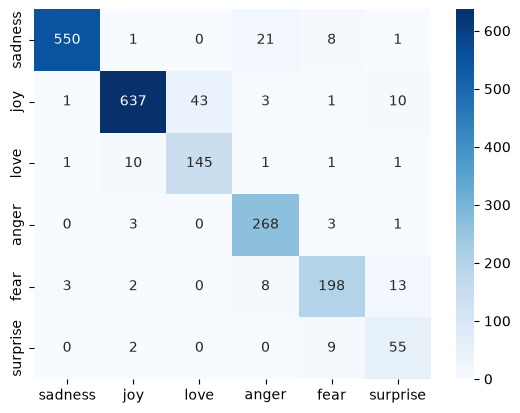

In [23]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequence),axis=1)

sns.heatmap(confusion_matrix(test_label, BiGRU_predictions),annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
   

### Lets make predictions

In [24]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
  print(f'Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}')
     

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Text: I can't believe how happy I am right now, this is amazing!
Predicted Emotion: joy
Text: I feel so alone and hopeless today.
Predicted Emotion: sadness
Text: I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger
Text: I feel terrified when walking down dark alleyways alone.
Predicted Emotion: fear
Text: I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: surprise


### Lets save the  train model for API deployment

In [25]:
import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True) 

#Save our BiGRU Model
BiGRU.save(os.path.join(model_dir, 'BiGRU_Model.keras'))

#Save the tokenizer model
with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
  pickle.dump(tokenizer, file)
     